In [1]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
def objective_fn(x, y):
    return x**2 - y**2

r = 5.0

def constraint_fn(x, y):
    return x**2 + y**2 - r**2

In [3]:
x_lin = np.linspace(-10, 10, 20)
y_lin = np.linspace(-10, 10, 20)
mesh_x, mesh_y = np.meshgrid(x_lin, y_lin)

z_surf = objective_fn(mesh_x, mesh_y)

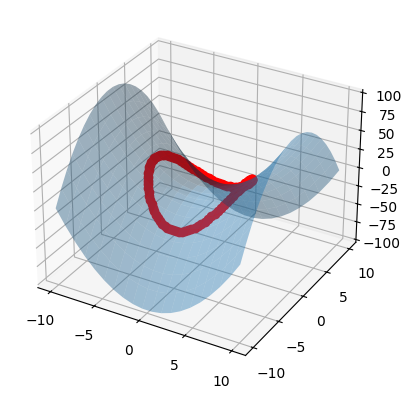

In [4]:


phi = np.linspace(0.0, 2 * np.pi, 100)
x = np.cos(phi) * r
y = np.sin(phi) * r
z = objective_fn(x, y)

fig = plt.figure()
ax = fig.add_subplot(projection = '3d')
ax.plot_surface(mesh_x, mesh_y, z_surf, alpha=0.4)
ax.plot(x, y, z, c='r', marker='o')

In [ ]:
import sympy as sp

x_sp, y_sp, lam_sp = sp.symbols('x y lambda')
f = objective_fn(x_sp, y_sp)
g = constraint_fn(x_sp, y_sp)
lagrangian = f - lam_sp * g
lagrangian

lambda*(x**2 + y**2 - 25.0) + x**2 - y**2

In [6]:
dLdx = lagrangian.diff(x_sp)
dLdy = lagrangian.diff(y_sp)
dLdl = lagrangian.diff(lam_sp)

In [7]:
# Solve system of equations
solutions = sp.solve([dLdx, dLdy, dLdl], (x_sp, y_sp, lam_sp))
solutions

[(-5.00000000000000, 0.0, -1.00000000000000),
 (5.00000000000000, 0.0, -1.00000000000000),
 (0.0, -5.00000000000000, 1.00000000000000),
 (0.0, 5.00000000000000, 1.00000000000000)]

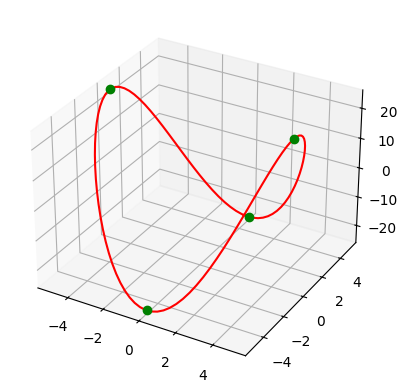

In [8]:
lr = 0.001
iters = 1000

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(x, y, z, c='r')
solutions = np.array(solutions).T
ax.plot(solutions[0], solutions[1], objective_fn(solutions[0], solutions[1]), c='g', marker='o', linestyle='None')